### Problem Definition

- **Tujuan Bisnis:** Memprediksi risiko gagal bayar calon peminjam secara akurat untuk meminimalkan kredit macet (False Negative Rendah) sekaligus menjaga tingkat persetujuan nasabah potensial (False Positive Rendah) guna penyusunan personalisasi struktur pinjaman.
- **Tipe  ML:** Supervised Learning - Binary Classification (0 = Lancar, 1 = Gagal/Default).
- **Metrik Keberhasilan:**
    - Model: PR-AUC, Recall, F1-Score, ROC-AUC/Gini Coefficient.
    - Bisnis: Penurunan rasio NPL (Non-Performing Loan) dan Optimalisasi Approval Rate.

### Data Collection

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
RANDOM_STATE = 42

In [2]:
df = pd.read_csv('application_train.csv')

print('Dataset shape:', df.shape)
print('\nOverview 5 sampel data:')
display(df.head())

Dataset shape: (307511, 122)

Overview 5 sampel data:


,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


### Data Cleaning

In [3]:
# handling code gender
xna = (df['CODE_GENDER'] == 'XNA').sum()
df = df[df['CODE_GENDER'] != 'XNA']
print('Jumlah baris XNA yang akan dihapus', xna)

# handling value age & year employed
df = df.assign(
    AGE = df['DAYS_BIRTH'].abs() / 365,
    YEARS_EMPLOYED = df['DAYS_EMPLOYED'].replace(365243, np.nan).abs() / 365
).drop(columns=['DAYS_BIRTH', 'DAYS_EMPLOYED'])
df[['CODE_GENDER', 'AGE', 'YEARS_EMPLOYED']]

Jumlah baris XNA yang akan dihapus 4


,CODE_GENDER,AGE,YEARS_EMPLOYED
0,M,25.920548,1.745205
1,F,45.931507,3.254795
2,M,52.180822,0.616438
3,F,52.068493,8.326027
4,M,54.608219,8.323288
...,...,...,...
307506,M,25.553425,0.646575
307507,F,56.917808,NaN
307508,F,41.002740,21.701370
307509,F,32.769863,13.112329


### EDA Basic

In [4]:
print('Dataset info:')
df.info()

Dataset info:
<class 'pandas.DataFrame'>
Index: 307507 entries, 0 to 307510
Columns: 122 entries, SK_ID_CURR to YEARS_EMPLOYED
dtypes: float64(67), int64(39), str(16)
memory usage: 288.6 MB


In [5]:
missing = pd.DataFrame({
    'Missing Count': df.isnull().sum(),
    'Missing Pct': df.isnull().mean() * 100
})
missing_analisis = (
    missing[missing['Missing Count'] > 0]
    .sort_values(by='Missing Pct', ascending=False)
)
print('Analisis missing value Top (25):')
display(missing_analisis.head(25))

Analisis missing value Top (25):


,Missing Count,Missing Pct
COMMONAREA_MODE,214862,69.872231
COMMONAREA_MEDI,214862,69.872231
COMMONAREA_AVG,214862,69.872231
NONLIVINGAPARTMENTS_AVG,213512,69.433216
NONLIVINGAPARTMENTS_MEDI,213512,69.433216
NONLIVINGAPARTMENTS_MODE,213512,69.433216
FONDKAPREMONT_MODE,210293,68.386411
LIVINGAPARTMENTS_MODE,210197,68.355192
LIVINGAPARTMENTS_MEDI,210197,68.355192
LIVINGAPARTMENTS_AVG,210197,68.355192


In [6]:
print('Jumlah data duplikat:', df.duplicated().sum())

print('\nStatistik deskriptif kolom numerik:')
df.describe()

Jumlah data duplikat: 0

Statistik deskriptif kolom numerik:


,SK_ID_CURR,TARGET,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,REGION_POPULATION_RELATIVE,DAYS_REGISTRATION,DAYS_ID_PUBLISH,...,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR,AGE,YEARS_EMPLOYED
count,307507.000000,307507.00000,307507.000000,3.075070e+05,3.075070e+05,307495.000000,3.072290e+05,307507.000000,307507.000000,307507.000000,...,307507.000000,307507.000000,265988.000000,265988.000000,265988.000000,265988.000000,265988.000000,265988.000000,307507.000000,252133.000000
mean,278181.527256,0.08073,0.417047,1.687977e+05,5.990286e+05,27108.666786,5.383977e+05,0.020868,-4986.131376,-2994.201670,...,0.000507,0.000335,0.006403,0.007000,0.034362,0.267388,0.265474,1.899950,43.937061,6.531897
std,102790.132982,0.27242,0.722119,2.371246e+05,4.024926e+05,14493.798379,3.694472e+05,0.013831,3522.883030,1509.454566,...,0.022518,0.018299,0.083850,0.110758,0.204686,0.915994,0.794060,1.869286,11.956116,6.406377
min,100002.000000,0.00000,0.000000,2.565000e+04,4.500000e+04,1615.500000,4.050000e+04,0.000290,-24672.000000,-7197.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,20.517808,0.000000
25%,189146.500000,0.00000,0.000000,1.125000e+05,2.700000e+05,16524.000000,2.385000e+05,0.010006,-7479.500000,-4299.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,34.008219,2.101370
50%,278203.000000,0.00000,0.000000,1.471500e+05,5.135310e+05,24903.000000,4.500000e+05,0.018850,-4504.000000,-3254.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,43.150685,4.515068
75%,367143.500000,0.00000,1.000000,2.025000e+05,8.086500e+05,34596.000000,6.795000e+05,0.028663,-2010.000000,-1720.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.000000,53.923288,8.698630
max,456255.000000,1.00000,19.000000,1.170000e+08,4.050000e+06,258025.500000,4.050000e+06,0.072508,0.000000,0.000000,...,1.000000,1.000000,4.000000,9.000000,8.000000,27.000000,261.000000,25.000000,69.120548,49.073973


In [7]:
print('Statistik kolom kategorikal:')
df.select_dtypes(include=['object']).describe()

Statistik kolom kategorikal:


,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,NAME_TYPE_SUITE,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,OCCUPATION_TYPE,WEEKDAY_APPR_PROCESS_START,ORGANIZATION_TYPE,FONDKAPREMONT_MODE,HOUSETYPE_MODE,WALLSMATERIAL_MODE,EMERGENCYSTATE_MODE
count,307507,307507,307507,307507,306215,307507,307507,307507,307507,211118,307507,307507,97214,153211,151167,161753
unique,2,2,2,2,7,8,5,6,6,18,7,58,4,3,7,2
top,Cash loans,F,N,Y,Unaccompanied,Working,Secondary / secondary special,Married,House / apartment,Laborers,TUESDAY,Business Entity Type 3,reg oper account,block of flats,Panel,No
freq,278232,202448,202922,213308,248523,158771,218389,196429,272865,55186,53900,67992,73829,150500,66039,159425


In [8]:
print('Distribusi target:')
df['TARGET'].value_counts()

Distribusi target:


TARGET
0    282682
1     24825
Name: count, dtype: int64

### Data Splitting

In [9]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=['SK_ID_CURR', 'TARGET'])
y = df['TARGET']

X_train_temp, X_test, y_train_temp, y_test = train_test_split(
    X, y, test_size=0.15, random_state=RANDOM_STATE, stratify=y
)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_temp, y_train_temp, test_size=(15/85), random_state=RANDOM_STATE, stratify=y_train_temp
)

print('Train shape:', X_train.shape, y_train.shape)
print('Val shape:', X_val.shape, y_val.shape)
print('Test shape:', X_test.shape, y_test.shape)

Train shape: (215254, 120) (215254,)
Val shape: (46126, 120) (46126,)
Test shape: (46127, 120) (46127,)


### EDA Advance

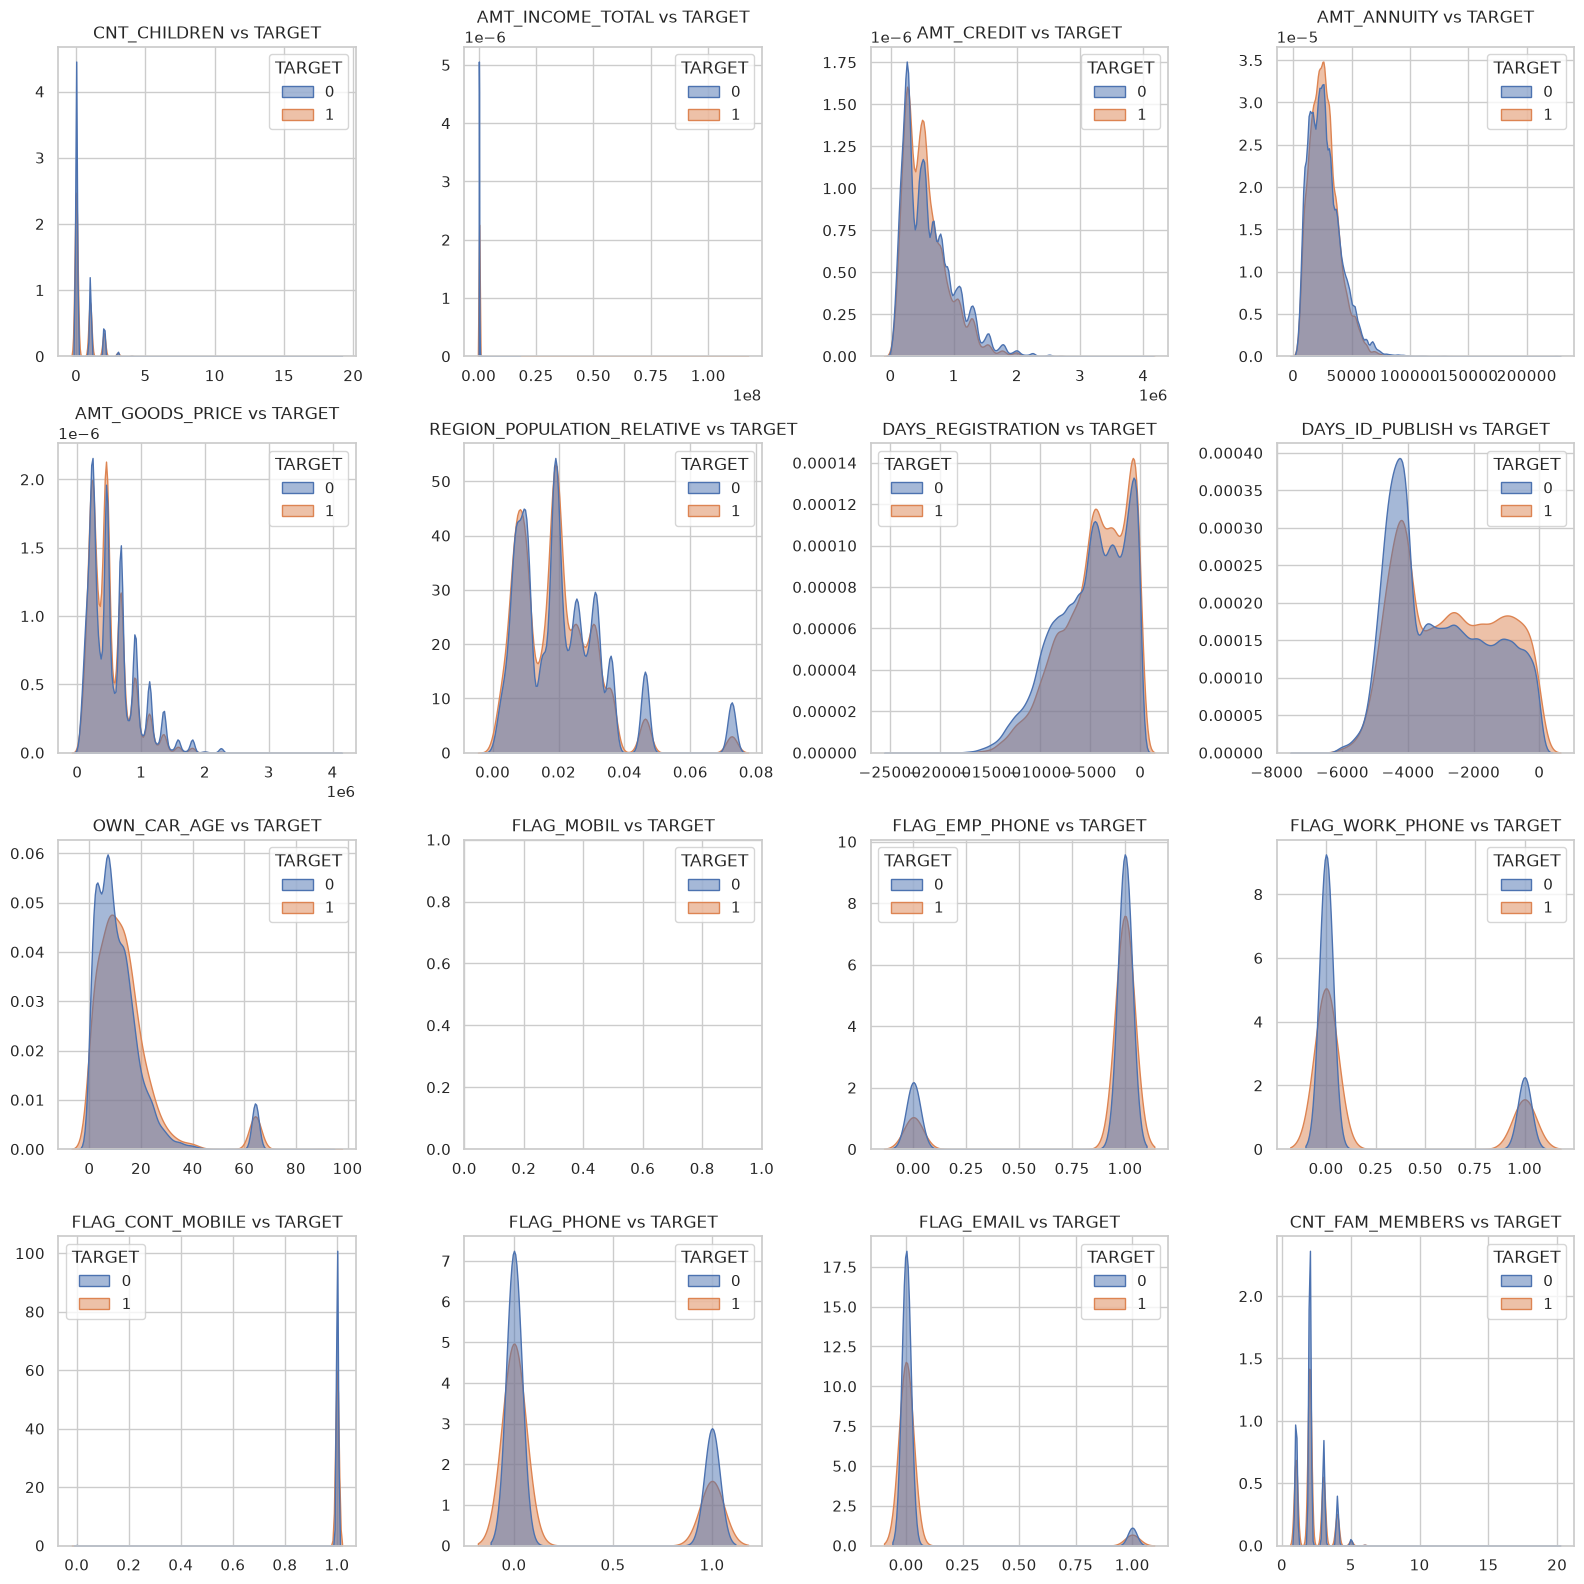

In [10]:
# korelasi fitur numerik terhadap TARGET
eda_df = X_train.copy()
eda_df['TARGET'] = y_train

num_feats = eda_df.select_dtypes(include=[np.number]).columns.drop('TARGET', errors='ignore')[:16]
n_cols = 4
n_rows = (len(num_feats) + n_cols -1) // n_cols

plt.figure(figsize=(16, 4 * n_rows))
for i, feat in enumerate(num_feats):
  plt.subplot(n_rows, n_cols, i + 1)
  sns.kdeplot(
      data=eda_df, x=feat, hue='TARGET', fill=True,
      common_norm=False, alpha=.5
  )
  plt.title(f'{feat} vs TARGET')
  plt.xlabel('')
  plt.ylabel('')
plt.tight_layout()
plt.show()


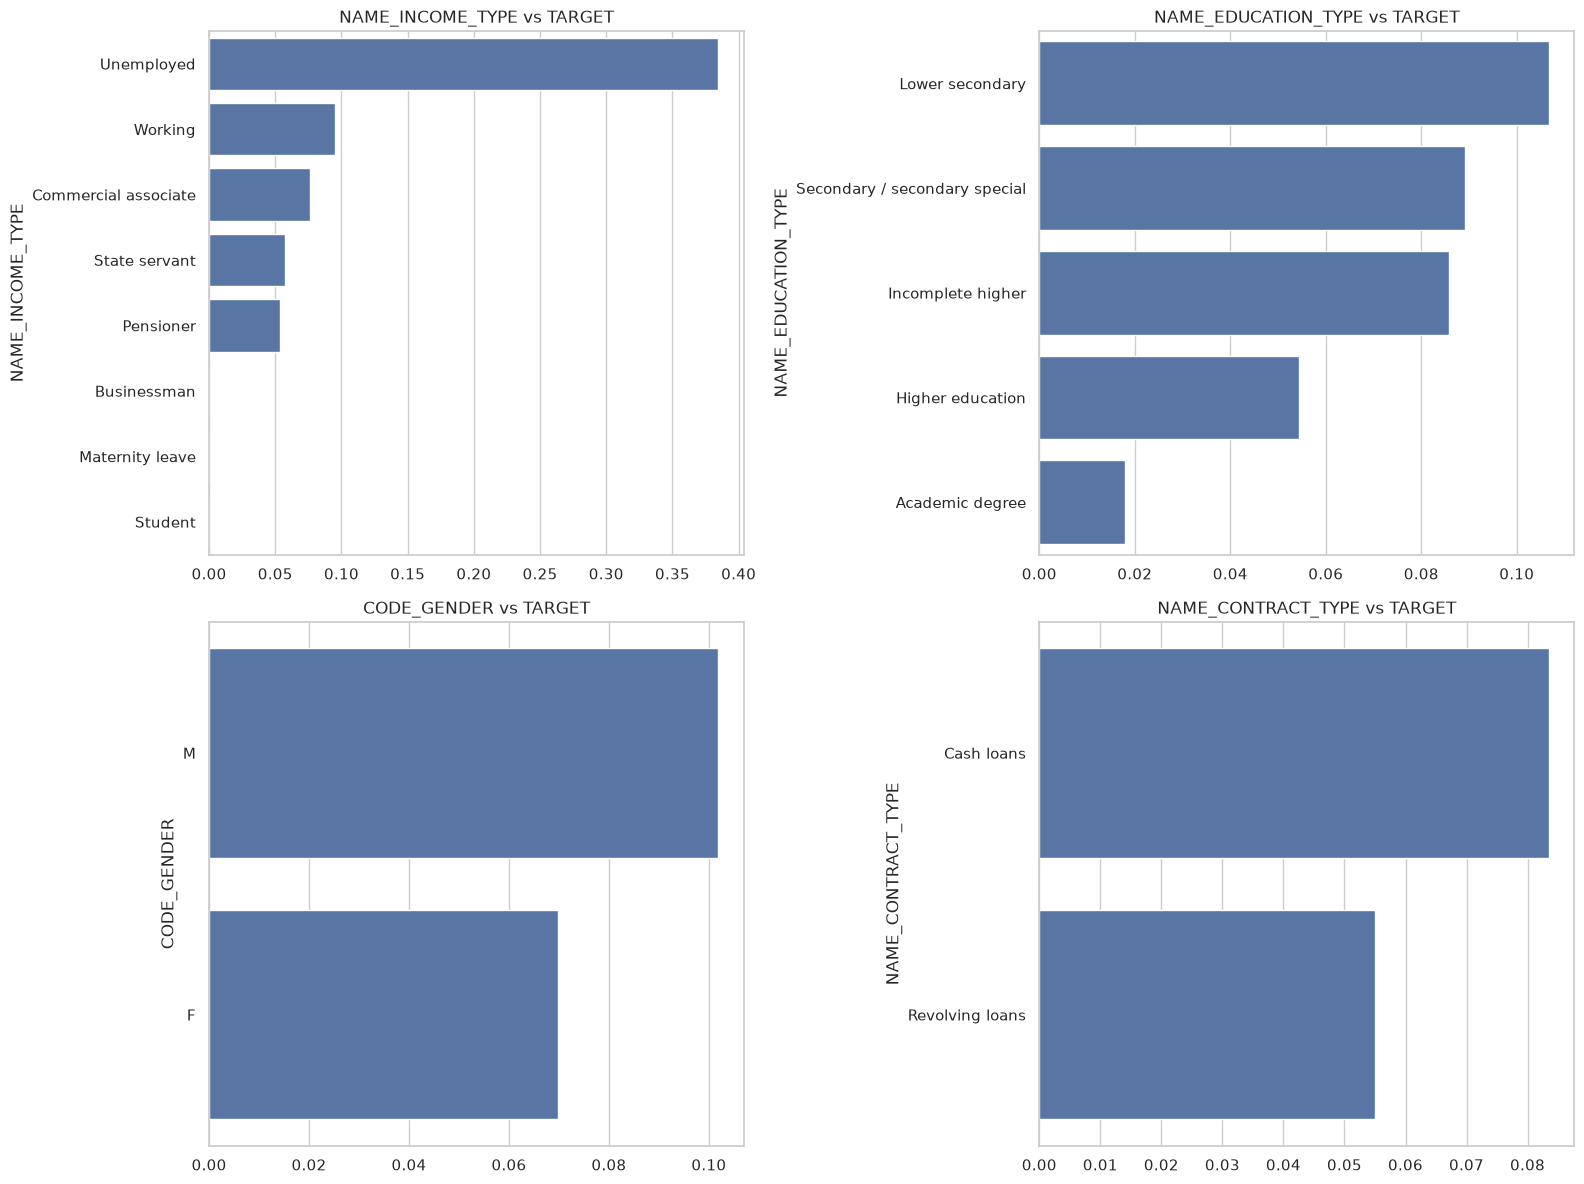

In [11]:
# analisis kategorikal terhadap default rate
cat_feats = ['NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE', 'CODE_GENDER', 'NAME_CONTRACT_TYPE']

plt.figure(figsize=(16, 12))
for i, feat in enumerate(cat_feats):
  plt.subplot(2, 2, i + 1)
  order_cat = eda_df.groupby(feat)['TARGET'].mean().sort_values(ascending=False).index

  sns.barplot(data=eda_df, x='TARGET', y=feat, order=order_cat, errorbar=None)
  plt.title(f'{feat} vs TARGET')
  plt.xlabel('')
plt.tight_layout()
plt.show()

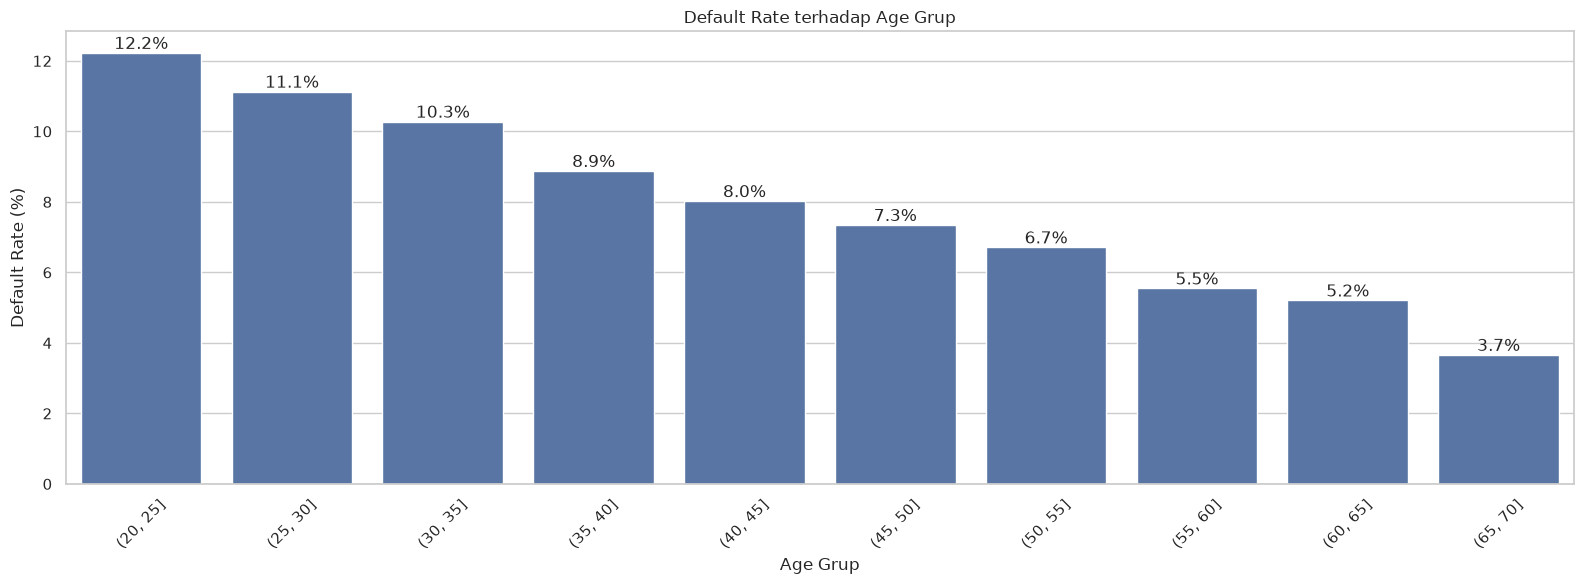

In [12]:
# analisis segmentasi default rete terhadap age grup
plt.figure(figsize=(16, 6))

age_bins = pd.cut(eda_df['AGE'], bins=np.arange(20, 75, 5))
age_groups = eda_df.groupby(age_bins)['TARGET'].mean() * 100

ax = sns.barplot(x=age_groups.index.astype(str), y=age_groups.values)

for container in ax.containers:
  ax.bar_label(container, fmt='%.1f%%')

plt.title('Default Rate terhadap Age Grup')
plt.xlabel('Age Grup')
plt.ylabel('Default Rate (%)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [13]:
# deteksi outlier
num_cols = eda_df.select_dtypes(include=[np.number]).columns

Q1 = eda_df[num_cols].quantile(0.25)
Q3 = eda_df[num_cols].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
is_outlier = (eda_df[num_cols] < lower_bound) | (eda_df[num_cols] > upper_bound)

outliers = is_outlier.sum(axis=0)
pct_cols = (outliers / len(eda_df)) * 100
skew_cols = eda_df[num_cols].skew()

outlier_summary = pd.DataFrame({
    'Jumlah Outlier': outliers,
    'Persentase (%)': pct_cols.round(2),
    'Skewness': skew_cols.round(2)
})
print('Summary outlier:')
display(outlier_summary.nlargest(25, 'Jumlah Outlier'))

Summary outlier:


,Jumlah Outlier,Persentase (%),Skewness
REGION_RATING_CLIENT,56344,26.18,0.09
REGION_RATING_CLIENT_W_CITY,54626,25.38,0.06
REG_CITY_NOT_WORK_CITY,49674,23.08,1.28
FLAG_WORK_PHONE,42947,19.95,1.50
FLAG_EMP_PHONE,38731,17.99,-1.67
LIVE_CITY_NOT_WORK_CITY,38714,17.99,1.67
AMT_REQ_CREDIT_BUREAU_QRT,35407,16.45,149.95
AMT_REQ_CREDIT_BUREAU_MON,30589,14.21,7.87
DEF_30_CNT_SOCIAL_CIRCLE,24751,11.50,3.86
FLAG_DOCUMENT_6,18913,8.79,2.91


In [14]:
# pola missing value dengan indikasi MNAR
eda_mnar = X_train.isnull().astype(int)
eda_mnar['TARGET'] = y_train.values

corr_missing = eda_mnar.corr()['TARGET'].drop('TARGET').abs().sort_values(ascending=False)
top_missing = corr_missing.head(25)
print('Korelasi status missing perkolom terhadap TARGET:')
display(top_missing)

Korelasi status missing perkolom terhadap TARGET:


YEARS_EMPLOYED                  0.045951
EMERGENCYSTATE_MODE             0.041853
TOTALAREA_MODE                  0.041521
FLOORSMAX_MEDI                  0.040696
FLOORSMAX_MODE                  0.040696
FLOORSMAX_AVG                   0.040696
ENTRANCES_MODE                  0.040568
ENTRANCES_MEDI                  0.040568
ENTRANCES_AVG                   0.040568
YEARS_BEGINEXPLUATATION_MEDI    0.040551
YEARS_BEGINEXPLUATATION_AVG     0.040551
YEARS_BEGINEXPLUATATION_MODE    0.040551
LIVINGAREA_AVG                  0.039720
LIVINGAREA_MODE                 0.039720
LIVINGAREA_MEDI                 0.039720
APARTMENTS_MEDI                 0.039658
APARTMENTS_AVG                  0.039658
APARTMENTS_MODE                 0.039658
HOUSETYPE_MODE                  0.039602
WALLSMATERIAL_MODE              0.039019
NONLIVINGAREA_MEDI              0.038882
NONLIVINGAREA_AVG               0.038882
NONLIVINGAREA_MODE              0.038882
ELEVATORS_AVG                   0.038799
ELEVATORS_MODE  

### Preprocessing & Feat Engginering

In [15]:
num_cols = X_train.select_dtypes(include=np.number).columns
cat_cols = X_train.select_dtypes(include=['object']).columns

train_median = X_train[num_cols].median()
train_mode = X_train[cat_cols].mode().iloc[0]

for df in [X_train, X_val, X_test]:
  # imputasi manual
  df[num_cols] = df[num_cols].fillna(train_median)
  df[cat_cols] = df[cat_cols].fillna(train_mode)

  # feature creation
  df['CREDIT_INCOME_RATIO'] = df['AMT_CREDIT'] / df['AMT_INCOME_TOTAL']
  df['ANNUITY_INCOME_RATIO'] = df['AMT_ANNUITY'] / df['AMT_INCOME_TOTAL']
  df['CREDIT_TERM'] = df['AMT_ANNUITY'] / df['AMT_CREDIT']

  # handling infinite value
  ratio_cols = ['CREDIT_INCOME_RATIO', 'ANNUITY_INCOME_RATIO', 'CREDIT_TERM']
  df[ratio_cols] = df[ratio_cols].replace([np.inf, -np.inf], np.nan)

In [16]:
financial_cols = ['AMT_GOODS_PRICE', 'AMT_CREDIT', 'AMT_ANNUITY', 'AMT_INCOME_TOTAL']
for df in [X_train, X_val, X_test]:
  for col in financial_cols:
    if col in df.columns:
      df[col] = np.log1p(df[col])

# outlier capping
count_cols = [
    'DEF_30_CNT_SOCIAL_CIRCLE', 'DEF_60_CNT_SOCIAL_CIRCLE',
    'OBS_30_CNT_SOCIAL_CIRCLE', 'OBS_60_CNT_SOCIAL_CIRCLE',
    'AMT_REQ_CREDIT_BUREAU_QRT', 'AMT_REQ_CREDIT_BUREAU_MON',
    'AMT_REQ_CREDIT_BUREAU_WEEK', 'AMT_REQ_CREDIT_BUREAU_YEAR'
]
for col in count_cols:
  if col in X_train.columns:
    bound = X_train[col].quantile(.99)
    for df in [X_train, X_val, X_test]:
      df[col] = np.where(df[col] > bound, bound, df[col])

for df in [X_train, X_val, X_test]:
  if 'CNT_CHILDREN' in df.columns:
    df['CNT_CHILDREN'] = np.minimum(df['CNT_CHILDREN'], 5)
  if 'CNT_FAM_MEMBERS' in df.columns:
    df['CNT_FAM_MEMBERS'] = np.minimum(df['CNT_FAM_MEMBERS'], 7)

In [17]:
# feature selection
num_cols = X_train.select_dtypes(include=np.number).columns
corr_matrix = X_train[num_cols].corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

# cari feat dengan corr 0.9
drop_corr = [col for col in upper.columns if any(upper[col] > 0.9)]
print(f'Fitur dengan korelasi 0.9: {drop_corr}')

X_train = X_train.drop(columns=drop_corr)
X_val = X_val.drop(columns=drop_corr)
X_test = X_test.drop(columns=drop_corr)

Fitur dengan korelasi 0.9: ['AMT_GOODS_PRICE', 'REGION_RATING_CLIENT_W_CITY', 'APARTMENTS_MODE', 'BASEMENTAREA_MODE', 'YEARS_BEGINEXPLUATATION_MODE', 'YEARS_BUILD_MODE', 'COMMONAREA_MODE', 'ELEVATORS_MODE', 'ENTRANCES_MODE', 'FLOORSMAX_MODE', 'FLOORSMIN_MODE', 'LANDAREA_MODE', 'LIVINGAPARTMENTS_MODE', 'LIVINGAREA_MODE', 'NONLIVINGAPARTMENTS_MODE', 'NONLIVINGAREA_MODE', 'APARTMENTS_MEDI', 'BASEMENTAREA_MEDI', 'YEARS_BEGINEXPLUATATION_MEDI', 'YEARS_BUILD_MEDI', 'COMMONAREA_MEDI', 'ELEVATORS_MEDI', 'ENTRANCES_MEDI', 'FLOORSMAX_MEDI', 'FLOORSMIN_MEDI', 'LANDAREA_MEDI', 'LIVINGAPARTMENTS_MEDI', 'LIVINGAREA_MEDI', 'NONLIVINGAPARTMENTS_MEDI', 'NONLIVINGAREA_MEDI', 'TOTALAREA_MODE', 'OBS_60_CNT_SOCIAL_CIRCLE']


Pipeline Preprocessing

In [18]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

num_cols = X_train.select_dtypes(include=np.number).columns.tolist()
cat_cols = X_train.select_dtypes(include=['object']).columns.tolist()

num_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])
cat_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])
preprocessor = ColumnTransformer(
    transformers=[
        ('num', num_transformer, num_cols),
        ('cat',cat_transformer, cat_cols)
    ]
)

# fit dan transform
X_train_prep = preprocessor.fit_transform(X_train)
X_val_prep = preprocessor.transform(X_val)
X_test_prep = preprocessor.transform(X_test)

print('Final dataset setelah preprocessing:')
print('Train shape:', X_train_prep.shape)
print('Val shape:', X_val_prep.shape)
print('Test shape:', X_test_prep.shape)

Final dataset setelah preprocessing:
Train shape: (215254, 214)
Val shape: (46126, 214)
Test shape: (46127, 214)


### Model Selection

In [19]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    average_precision_score,
    classification_report,
    confusion_matrix,
    fbeta_score,
    precision_recall_curve,
    roc_auc_score
)
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold

CV = StratifiedKFold(
    n_splits=3,
    shuffle=True,
    random_state=RANDOM_STATE
)

lr = LogisticRegression(
    class_weight='balanced',
    max_iter=1000,
    random_state=RANDOM_STATE
)
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    min_samples_leaf=20,
    class_weight='balanced',
    random_state=RANDOM_STATE,
    n_jobs=-1
)

models = {
    'Logistic Regression': lr,
    'Random Forest': rf
}
print('Model yang akan diuji:')
for name in models:
  print(f'-{name}')

print('\nStrategi CV: Stratified K-Fold')
print('- Splits: ', CV.get_n_splits())


Model yang akan diuji:
-Logistic Regression
-Random Forest

Strategi CV: Stratified K-Fold
- Splits:  3


### Model Training

In [20]:
results = []

for name, model in models.items():
  print(f'\nMelatih: {name}')

  model.fit(X_train_prep, y_train)
  y_proba = model.predict_proba(X_val_prep)[:, 1]
  y_pred = model.predict(X_val_prep)

  roc_auc = roc_auc_score(y_val, y_proba)
  pr_auc = average_precision_score(y_val, y_proba)

  print(f'ROC-AUC (Val): {roc_auc:.4f}')
  print(f'PR-AUC (Val): {pr_auc:.4f}')
  print('\nClassification Report:')
  print(classification_report(y_val, y_pred, digits=4))

  results.append({
      'Model': name,
      'ROC-AUC (Val)': roc_auc,
      'PR-AUC (Val)': pr_auc
  })

summary = pd.DataFrame(results).sort_values(by='PR-AUC (Val)', ascending=False)
print('\nSummary model:')
display(summary)


Melatih: Logistic Regression
ROC-AUC (Val): 0.7536
PR-AUC (Val): 0.2284

Classification Report:
              precision    recall  f1-score   support

           0     0.9611    0.6899    0.8033     42402
           1     0.1620    0.6823    0.2618      3724

    accuracy                         0.6893     46126
   macro avg     0.5615    0.6861    0.5325     46126
weighted avg     0.8966    0.6893    0.7595     46126


Melatih: Random Forest
ROC-AUC (Val): 0.7431
PR-AUC (Val): 0.2170

Classification Report:
              precision    recall  f1-score   support

           0     0.9593    0.7044    0.8123     42402
           1     0.1639    0.6598    0.2625      3724

    accuracy                         0.7008     46126
   macro avg     0.5616    0.6821    0.5374     46126
weighted avg     0.8951    0.7008    0.7679     46126


Summary model:


,Model,ROC-AUC (Val),PR-AUC (Val)
0,Logistic Regression,0.753591,0.228446
1,Random Forest,0.743115,0.217008


### Model Evaluation & Tuning

In [ ]:
param_dist = {
    'n_estimators': [200, 300, 500],
    'max_depth': [5, 8, 10, 12],
    'min_samples_split': [10, 20, 30],
    'min_samples_leaf': [10, 20, 30, 50],
    'max_features': ['sqrt', 'log2'],
    'max_samples': [0.6, 0.7, 0.8]
}

rf_search = RandomizedSearchCV(
    estimator=RandomForestClassifier(
        class_weight='balanced',
        random_state=RANDOM_STATE,
        n_jobs=1,
        bootstrap=True,
        ccp_alpha=0.0001
    ),
    param_distributions=param_dist,
    n_iter=25,
    scoring='average_precision',
    cv=CV,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    pre_dispatch='2*n_jobs',
    verbose=1
)

rf_search.fit(X_train_prep, y_train)
print('Best params:', rf_search.best_params_)
print(f'Best CV PR-AUC (Train): {rf_search.best_score_:.4f}')

best_model = rf_search.best_estimator_

train_check = average_precision_score(y_train, best_model.predict_proba(X_train_prep)[:, 1])
print(f'PR-AUC Train : {train_check:.4f}')
print(f'PR-AUC CV : {rf_search.best_score_:.4f}')
print(f'Gap (Train-CV): {train_check - rf_search.best_score_:.4f}')

Fitting 3 folds for each of 25 candidates, totalling 75 fits
Best params: {'n_estimators': 200, 'min_samples_split': 10, 'min_samples_leaf': 10, 'max_samples': 0.8, 'max_features': 'sqrt', 'max_depth': 12}
Best CV PR-AUC (Train): 0.2102
PR-AUC Train : 0.2349
PR-AUC CV : 0.2102
Gap (Train-CV): 0.0247


In [22]:
y_train_proba = best_model.predict_proba(X_train_prep)[:, 1]
y_val_proba = best_model.predict_proba(X_val_prep)[:, 1]

train_pr_auc = average_precision_score(y_train, y_train_proba)
val_pr_auc = average_precision_score(y_val, y_val_proba)
gap = train_pr_auc - val_pr_auc

print(f'PR-AUC Train: {train_pr_auc:.4f}')
print(f'PR-AUC Val: {val_pr_auc:.4f}')
print(f'Gap (Train-Val): {gap:.4f}')

PR-AUC Train: 0.2349
PR-AUC Val: 0.2167
Gap (Train-Val): 0.0182


In [23]:
precision, recalls, thresholds = precision_recall_curve(y_val, y_val_proba)
f2_scores = (5 * precision * recalls) / (4 * precision + recalls + 1e-10)
f2_scores = f2_scores[:-1]

best_idx = np.argmax(f2_scores)
best_threshold = thresholds[best_idx]

print(f'Best F2 Score: {f2_scores[best_idx]:.4f}')
print(f'Best Threshold: {best_threshold:.4f}')
print(f'Best Recall: {recalls[best_idx]:.4f}')
print(f'Best Precision: {precision[best_idx]:.4f}')

Best F2 Score: 0.4134
Best Threshold: 0.4964
Best Recall: 0.6807
Best Precision: 0.1608


In [ ]:
y_test_proba = best_model.predict_proba(X_test_prep)[:, 1]
y_test_pred_final = (y_test_proba >= best_threshold).astype(int)

test_roc_auc = roc_auc_score(y_test, y_test_proba)
test_gini = 2 *  test_roc_auc - 1
test_pr_auc = average_precision_score(y_test, y_test_proba)
test_f2 = fbeta_score(y_test, y_test_pred_final, beta=2)

print('EVALUASI FINAL TEST')
print(f'Test ROC-AUC: {test_roc_auc:.4f}')
print(f'Test Gini Coefficient: {test_gini:.4f}')
print(f'Test PR-AUC: {test_pr_auc:.4f}')
print(f'Test F2 Score: {test_f2:.4f}')
print('\nClassification Report:')
print(classification_report(y_test, y_test_pred_final, digits=4))
print('\nConfusion Matrix:')
print(confusion_matrix(y_test, y_test_pred_final))

EVALUASI FINAL TEST
Test ROC-AUC: 0.7449
Test PR-AUC: 0.2174
Test F2 Score: 0.4101

Classification Report:
              precision    recall  f1-score   support

           0     0.9601    0.6886    0.8020     42403
           1     0.1598    0.6743    0.2583      3724

    accuracy                         0.6874     46127
   macro avg     0.5599    0.6814    0.5302     46127
weighted avg     0.8955    0.6874    0.7581     46127


Confusion Matrix:
[[29198 13205]
 [ 1213  2511]]


In [25]:
tn, fp, fn, tp = confusion_matrix(y_test, y_test_pred_final).ravel()
approval_rate = (tn + fn) / len(y_test)
npl_baseline = y_test.mean()

nlp_after_model = fn / (tn + fn)

print('DAMPAK BISNIS PADA THRESHOLD OPTIMAL')
print(f'Approval Rate (persetujuan): {approval_rate:.2f}')
print(f'NPL rate tanpa model (baseline): {npl_baseline:.2f}')
print(f'NPL rate setelah filter model: {nlp_after_model:.2f}')
print(f'Recall (defaulter tertangkap): {tp / (tp + fn):.2%}')

DAMPAK BISNIS PADA THRESHOLD OPTIMAL
Approval Rate (persetujuan): 0.66
NPL rate tanpa model (baseline): 0.08
NPL rate setelah filter model: 0.04
Recall (defaulter tertangkap): 67.43%


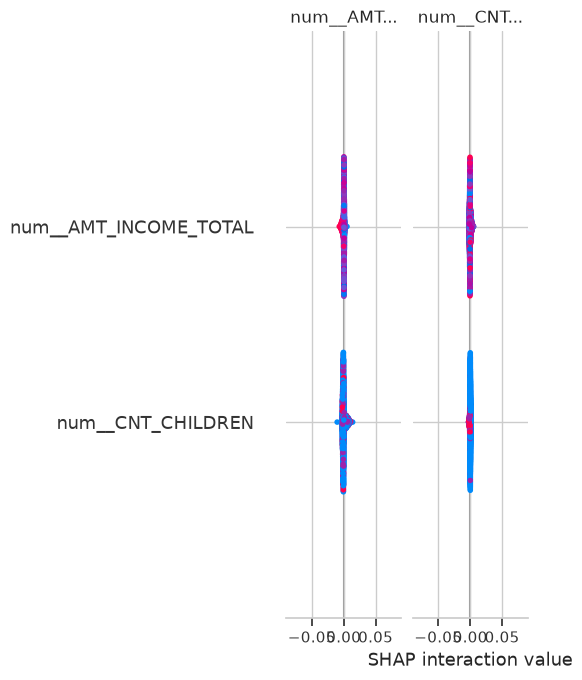

In [ ]:
import shap

rng = np.random.RandomState(RANDOM_STATE)
sample_idx = rng.choice(X_val_prep.shape[0], size=min(2000, X_val_prep.shape[0]), replace=False)
X_val_sample = X_val_prep[sample_idx]

explainer = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_val_sample)

shap.summary_plot(
    shap_values[1] if isinstance(shap_values, list) else shap_values,
    X_val_sample,
    feature_names=preprocessor.get_feature_names_out(),
    show=True
)

### Model Deployment

### Model Monitoring & Maintenance